*** This Code is for Extracting ship information from NovaSAR images and their corresponding AIS data

In [1]:
# Import dependencies

import os
import numpy as np
import math
from datetime import datetime, date
import matplotlib.pyplot as plt


In [2]:
import rasterio as rio

# NovaSAR images

In [7]:
head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"
data_dir = "Airbus_2024Feb23"
# data_dir = "Airbus_2024Jan11"
# data_dir = "Airbus_2024Jun23"

In [8]:
import os

tif_files = []
for root, dirs, files in os.walk(head_dir+data_dir):
    for file in files:
        if file.lower().endswith('.tif'):
            tif_files.append(os.path.join(root, file))

tif_files = [f for f in tif_files if not os.path.basename(f).startswith('QL')] # Exclude files starting with 'QL' [These are low resolution files only for visualisation]
print(f"Found {len(tif_files)} tif files.")
tif_files

Found 140 tif files.


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222538_HH_1/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222549_HH_3/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222555_HH_4/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222600_HH_5/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082036_HH_1/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_g

In [9]:
import pandas as pd

# Load only the first 100 rows of a CSV file
csv_dir = "AIS_dataset/aisdk-2024-04-15/aisdk-2024-04-15.csv" 
# csv_dir = r"E:\AssenSAR\CSP LIDAR Data\NovaSAR\AIS_dataset\aisdk-2024-04-15\aisdk-2024-04-15.csv" 
df_partial = pd.read_csv(head_dir+csv_dir, nrows=150000)
df_partial[9000:15000]  # Display rows 100 to 1100

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
9000,15/04/2024 00:00:53,Class A,209583000,55.453068,8.454555,Unknown value,0.0,0.0,231.6,293.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
9001,15/04/2024 00:00:53,Class A,230643000,55.015873,14.089327,Under way using engine,0.0,19.0,70.4,70.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
9002,15/04/2024 00:00:53,Class A,209583000,55.453068,8.454555,Unknown value,0.0,0.0,231.6,293.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
9003,15/04/2024 00:00:53,AtoN,992651028,56.888067,12.474000,Unknown value,NaN,NaN,NaN,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
9004,15/04/2024 00:00:53,AtoN,992651028,56.888067,12.474000,Unknown value,NaN,NaN,NaN,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,15/04/2024 00:01:28,Class A,211226330,54.338617,9.139875,Under way using engine,0.0,0.0,132.3,309.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
14996,15/04/2024 00:01:28,Class A,219429000,57.695895,9.767870,Engaged in fishing,NaN,1.0,17.3,313.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
14997,15/04/2024 00:01:28,Class A,219429000,57.695895,9.767870,Engaged in fishing,NaN,1.0,17.3,313.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
14998,15/04/2024 00:01:28,Class A,219186000,55.524617,5.018338,Under way using engine,42.9,2.0,47.5,10.0,...,NaN,Combined GPS/GLONASS,5.3,GORM,10/04/2024 22:20:00,AIS,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd

timestamp_col = '# Timestamp'
start_time = '15/04/2024 00:00:50'
end_time = '15/04/2024 00:00:55'

chunks = []
for chunk in pd.read_csv(head_dir+csv_dir, chunksize=500000):
    mask = (chunk[timestamp_col] >= start_time) & (chunk[timestamp_col] <= end_time)
    filtered = chunk[mask]
    if not filtered.empty:
        chunks.append(filtered)

df_time_range = pd.concat(chunks, ignore_index=True)
df_time_range

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,15/04/2024 00:00:50,Class A,311000971,57.437593,8.542957,Under way using engine,0.0,9.5,57.0,55.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,15/04/2024 00:00:50,Class A,538009249,55.403370,14.673745,Under way using engine,0.0,12.8,64.0,62.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,15/04/2024 00:00:50,Class A,219000873,56.990900,10.304548,Under way using engine,NaN,0.0,36.9,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,15/04/2024 00:00:50,Base Station,2190064,56.716572,11.519047,Unknown value,NaN,NaN,NaN,NaN,...,NaN,GPS,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,15/04/2024 00:00:50,Class A,219018494,56.958633,8.366400,Under way using engine,NaN,0.0,123.5,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,15/04/2024 00:00:55,Class A,219355000,55.889650,12.743333,Under way using engine,0.0,11.9,17.0,16.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1075,15/04/2024 00:00:55,Class A,636019547,54.649843,12.495763,Under way using engine,0.0,10.9,56.4,55.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1076,15/04/2024 00:00:55,Class A,257723000,55.488638,6.990868,Under way using engine,0.0,7.8,99.2,97.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1077,15/04/2024 00:00:55,Class A,265704020,57.109640,12.241550,Engaged in fishing,NaN,0.0,NaN,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [10]:
import xml.etree.ElementTree as ET
file_path = f"{tif_files[0][:-12]}metadata.xml"
tree = ET.parse(file_path)
root = tree.getroot()
# Find the "geographicInformation" element in the XML metadata
geo_info_elem = root.find(".//geographicInformation")
if geo_info_elem is not None:
    print(ET.tostring(geo_info_elem, encoding='unicode'))
else:
    print("geographicInformation element not found.")

<geographicInformation>
      <EllipsoidName>WGS84</EllipsoidName>
      <SemiMajorAxis units="metres">6378137.0</SemiMajorAxis>
      <SemiMinorAxis units="metres">6356752.3</SemiMinorAxis>
      <MeanTerrainHeight units="metres">75</MeanTerrainHeight>
      <NumberOfRangeTiepoints>6</NumberOfRangeTiepoints>
      <NumberOfAzimuthTiepoints>6</NumberOfAzimuthTiepoints>
      <TiePoint>
         <Line>0</Line>
         <Pixel>0</Pixel>
         <Latitude units="deg">       56.0471625</Latitude>
         <Longitude units="deg">      11.02509456</Longitude>
         <Height units="m">          75</Height>
      </TiePoint>
      <TiePoint>
         <Line>0</Line>
         <Pixel>1585</Pixel>
         <Latitude units="deg">      56.03569684</Latitude>
         <Longitude units="deg">      11.08545497</Longitude>
         <Height units="m">          75</Height>
      </TiePoint>
      <TiePoint>
         <Line>0</Line>
         <Pixel>3171</Pixel>
         <Latitude units="deg">      56.024

In [11]:
# Extract the text of the "EllipsoidName" element from geo_info_elem
ellipsoid_elem = geo_info_elem.find(".//EllipsoidName")
ellipsoid_name = ellipsoid_elem.text if ellipsoid_elem is not None else None
print("EllipsoidName:", ellipsoid_name)

EllipsoidName: WGS84


In [12]:
im_attr_info_elem = root.find(".//Image_Attributes")

elem = im_attr_info_elem.find(".//SampledLineSpacing")
SampledLineSpacing_name = elem.text if elem is not None else None
print("SampledLineSpacing:", SampledLineSpacing_name)
elem = im_attr_info_elem.find(".//SampledPixelSpacing")
SampledPixelSpacing_name = elem.text if elem is not None else None
print("SampledPixelSpacing:", SampledLineSpacing_name)

elem = geo_info_elem.find(".//SemiMajorAxis")
SemiMajorAxis_name = elem.text if elem is not None else None
print("SemiMajorAxis:", SemiMajorAxis_name)
elem = geo_info_elem.find(".//SemiMinorAxis")
SemiMinorAxis_name = elem.text if elem is not None else None
print("SemiMinorAxis:", SemiMinorAxis_name)

SampledLineSpacing: 2.50
SampledPixelSpacing: 2.50
SemiMajorAxis: 6378137.0
SemiMinorAxis: 6356752.3


In [13]:
# Extract tie point information from the "geographicInformation" element
tiepoints = []
for tp in geo_info_elem.findall(".//TiePoint"):
    line = tp.findtext("Line")
    pixel = tp.findtext("Pixel")
    lat = tp.findtext("Latitude")
    lon = tp.findtext("Longitude")
    height = tp.findtext("Height")
    tiepoints.append({
        "line": line,
        "pixel": pixel,
        "lat": lat,
        "lon": lon,
        "height": height
    })

# Display the extracted tiepoints
for tp in tiepoints:
    print(tp)

{'line': '0', 'pixel': '0', 'lat': '       56.0471625', 'lon': '      11.02509456', 'height': '          75'}
{'line': '0', 'pixel': '1585', 'lat': '      56.03569684', 'lon': '      11.08545497', 'height': '          75'}
{'line': '0', 'pixel': '3171', 'lat': '      56.02419515', 'lon': '      11.14581384', 'height': '          75'}
{'line': '0', 'pixel': '4756', 'lat': '      56.01267229', 'lon': '      11.20609336', 'height': '          75'}
{'line': '0', 'pixel': '6342', 'lat': '       56.0011134', 'lon': '      11.26637142', 'height': '          75'}
{'line': '0', 'pixel': '7927', 'lat': '      55.98953387', 'lon': '      11.32656791', 'height': '          75'}
{'line': '3171', 'pixel': '0', 'lat': '      55.97961231', 'lon': '      10.98498684', 'height': '          75'}
{'line': '3171', 'pixel': '1585', 'lat': '      55.96816518', 'lon': '      11.04524022', 'height': '          75'}
{'line': '3171', 'pixel': '3171', 'lat': '      55.95668204', 'lon': '      11.10549263', 'heigh

In [37]:
def gsd_meters_to_degrees(lat_deg, lon_deg, gsd_m, ellps="WGS84"):
    from pyproj import Geod
    # Define WGS84 ellipsoid
    geod = Geod(ellps=ellps)

    # Move eastward by gsd_m
    lon2, lat2, _ = geod.fwd(lon_deg, lat_deg, az=90, dist=gsd_m)
    delta_lon = lon2 - lon_deg

    # Move northward by gsd_m
    lon3, lat3, _ = geod.fwd(lon_deg, lat_deg, az=0, dist=gsd_m)
    delta_lat = lat3 - lat_deg

    return delta_lon, delta_lat

In [ ]:
from rasterio.crs import CRS
from rasterio.transform import Affine

# Use ellipsoid parameters for CRS, fallback to WGS84 if not available
if ellipsoid_name == "WGS84":
    crs = CRS.from_epsg(4326)
else:
    crs = CRS.from_string(f"+proj=longlat +a={SemiMajorAxis_name} +b={SemiMinorAxis_name} +no_defs")

# Use tiepoints and sampling info to create transform
if tiepoints and SampledPixelSpacing_name and SampledLineSpacing_name:
    tp0 = tiepoints[-1]#[0]
    pixel_size_x, pixel_size_y = gsd_meters_to_degrees(float(tp0['lat']), float(tp0['lon']), float(SampledPixelSpacing_name), ellps=ellipsoid_name)

    origin_lon = float(tp0['lon'])
    origin_lat = float(tp0['lat'])
    
    # Affine: (pixel width, 0, top left x, 0, -pixel height, top left y)
    transform = Affine(pixel_size_x, 0, origin_lon, 0, -pixel_size_y, origin_lat)
else:
    transform = None

print("CRS:", crs)
print("Transform:", transform)
transform

CRS: EPSG:4326
Transform: | 0.00, 0.00, 11.12|
| 0.00,-0.00, 55.65|
| 0.00, 0.00, 1.00|


Affine(3.9712764989374705e-05, 0.0, 11.12467816,
       0.0, -2.245465474715047e-05, 55.65212433)

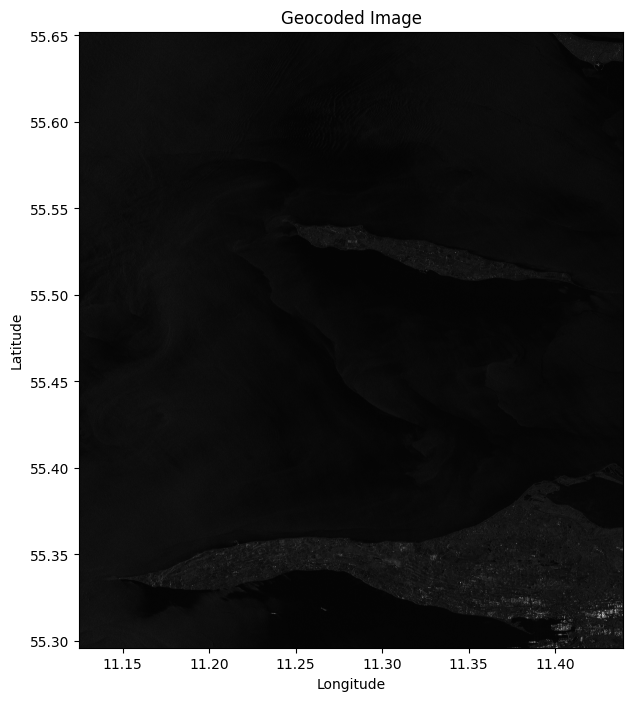

In [35]:
import rasterio.plot
with rio.open(tif_files[0]) as src:
    fig, ax = plt.subplots(figsize=(8, 8))
    rio.plot.show(src.read(1), ax=ax, transform=transform, cmap='gray', vmin=0, vmax=1500)
    ax.set_title("Geocoded Image")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.show()

## Working with .SAFE file using SNAPPY

In [ ]:
from esa_snappy import ProductIO


In [5]:
p = ProductIO.readProduct("E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\Copernicus\S1A_IW_GRDH_1SDV_20230831T181434_20230831T181459_050123_06082E_0B83_COG.zip")
list(p.getBandNames())

['Amplitude_VV', 'Intensity_VV', 'Amplitude_VH', 'Intensity_VH']

## RasterIO

In [3]:
dir = "E:\\AssenSAR\\CSP LIDAR Data\\Sentinel Data Download\\GEE\Sentinel1_Images_ShipPath\\"
dir = "E:\\AssenSAR\\CSP LIDAR Data\\Sentinel Data Download\\GEE\Sentinel1_Images_CaldeyIsland\\"
im_name_all = [f for f in os.listdir(dir) if f.lower().endswith('.tif')]
im_name_all

['Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220505T063942_20220505T064007_043072_0524BA_9119_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220508T181422_20220508T181447_043123_052660_6311_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220512T063129_20220512T063154_043174_0527F9_36AA_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220515T180607_20220515T180632_043225_052998_1A1E_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220517T063942_20220517T064007_043247_052A37_A933_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220520T181423_20220520T181448_043298_052BAC_326E_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220527T180607_20220527T180632_043400_052EC7_F105_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220529T063944_20220529T064009_043422_052F64_B17A_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220601T181424_20220601T181449_043473_0530DA_E670_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_2022060

In [4]:
import rasterio as rio
im_path = dir + im_name_all[0]
src=rio.open(im_path)

im = src.read()#1, window=((5000, 15000), (15000, 25000)))
im.shape

(3, 780, 1114)

In [5]:
im.shape[2]#%(im.shape[2]//4+1)

1114

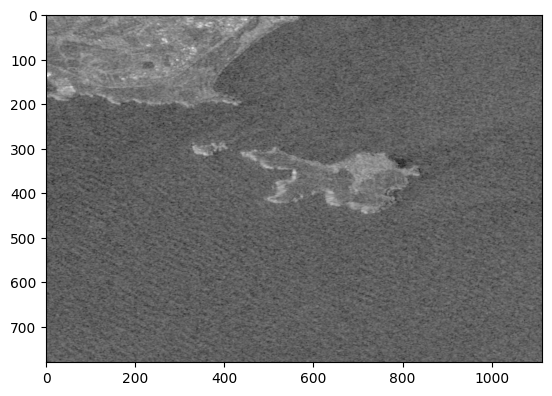

In [6]:
plt.imshow(im[0], cmap='gray')


In [7]:
# Function to export a subset of a raster image as a 512x512 window

def float_to_uint8(arr):
    """
    Rescale a float array to the range 0-255 and convert to uint8.
    """
    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)
    if arr_max == arr_min:
        return np.zeros_like(arr, dtype=np.uint8)
    scaled = (arr - arr_min) / (arr_max - arr_min) * 255
    return scaled.astype(np.uint8)

def export_subset(im_path, start_row=0, start_col=0, win_height=512, win_width=512, uint8=False, rgb='No', out_name="subset_output.tif"):
    """
    Exports a subset of a raster image as a 512x512 window.
    
    Parameters:
    - im_path: Path to the input raster image.
    - start_row: Starting row index for the window.
    - start_col: Starting column index for the window.
    - win_height: Height of the window.
    - win_width: Width of the window.
    - uint8: If True, converts the output to uint8 format.
    - rgb: If 'No', exports all bands (VV, VH, incidence angle); 
           if 'VV', repeats VV channel 3 times; 
           if 'VH', repeats VH channel 3 times;
           if 'all', [VV, VH, VV-VH]
    - out_name: Name of the output file.
    
    Returns:
    - None
    """
    from rasterio.windows import Window

    # Open the raster image
    with rio.open(im_path) as src:

        # Compute how much of the window is inside the image bounds
        read_height = min(win_height, src.height - start_row)
        read_width  = min(win_width, src.width - start_col)

        # Read the available portion
        window = Window( start_col, start_row, read_width, read_height )
        sub0 = src.read(window=window)

        if uint8:
            sub0[0:1, :, :] = float_to_uint8(sub0[0:1, :, :])
            sub0[1:2, :, :] = float_to_uint8(sub0[1:2, :, :])
            sub0[2:3, :, :] = float_to_uint8(sub0[2:3, :, :])

        if rgb == 'VV':
            sub0 = np.repeat(sub0[0:1, :, :], 3, axis=0)  # Repeat VV channel 3 times
        elif rgb == 'VH':
            sub0 = np.repeat(sub0[1:2, :, :], 3, axis=0)
        elif rgb == 'all':
            sub0 = np.concatenate((sub0[0:1, :, :], sub0[1:2, :, :], sub0[0:1, :, :] - sub0[1:2, :, :]), axis=0)
        elif rgb == 'No':
            pass

        # Check if the read dimensions match the desired window size:
        if read_height != win_height or read_width != win_width:
            # Pad with zeros to make it 512x512
            num_bands = sub0.shape[0]
            if uint8:
                sub = np.zeros( (num_bands, win_height, win_width), dtype=np.uint8 )
            else:
                sub = np.zeros( (num_bands, win_height, win_width), dtype=src.dtypes[0] )
            sub[:, :read_height, :read_width] = sub0
        else:
            sub = sub0

        # Adjust metadata:
        out_meta = src.meta.copy()
        out_meta.update({
            "height": win_height,
            "width": win_width,
            "transform": src.window_transform( Window(start_col, start_row, win_width, win_height) )
        })
        if uint8:
            out_meta["dtype"] = "uint8"

    # Write the output:
    with rio.open(out_name, "w", **out_meta) as dest:
        dest.write(sub)


In [ ]:
# Parameters
win_height, win_width = im.shape[1]//4+1, im.shape[2]//4+1 #320, 320
win_height, win_width = im.shape[1]//3+1, im.shape[2]//4+1 #320, 320

win_height = np.max([win_height, win_width]) # For square windows
win_width = win_height
print("Window size:", win_height, win_width)

Window size: 279 279


In [12]:
# Specify and Create output directory if it doesn't exist:

output_dir = os.path.join(dir, "Subsets")
output_dir = os.path.join(dir, "Subsets_RGB_VV"); uint8=True; rgb='VV'

if not os.path.exists(output_dir):
    print(f"Creating output directory: {output_dir}")
    os.makedirs(output_dir)

Creating output directory: E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV


In [13]:
# Loop through all images and export subsets:

for im_nameij in im_name_all:
    im_pathij = dir + im_nameij
    srcij = rio.open(im_pathij)

    print(f"Processing {im_nameij} with dimensions {srcij.width}x{srcij.height}")

    cc=1
    for ii in range(1+src.width//win_width):
        start_colii = ii * win_width
        for jj in range(1+src.height//win_height):
            start_rowjj= jj * win_height
            out_nameij = f"{output_dir}\\{im_nameij[:-4]}_rgb_{rgb}_sub{cc}.tif"
            
            export_subset(im_pathij, start_row=start_rowjj, start_col=start_colii, win_height=win_height, win_width=win_width, uint8=uint8, rgb=rgb, out_name=out_nameij)
            
            print(f"====> {cc} at row {start_rowjj}, col {start_colii} Exported {out_nameij}")
            cc += 1

Processing Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING.tif with dimensions 1114x780
====> 1 at row 0, col 0 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING_rgb_VV_sub1.tif
====> 2 at row 279, col 0 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING_rgb_VV_sub2.tif
====> 3 at row 558, col 0 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING_rgb_VV_sub3.tif
====> 4 at row 0, col 279 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV

Text(0.5, 0, 'Lon')

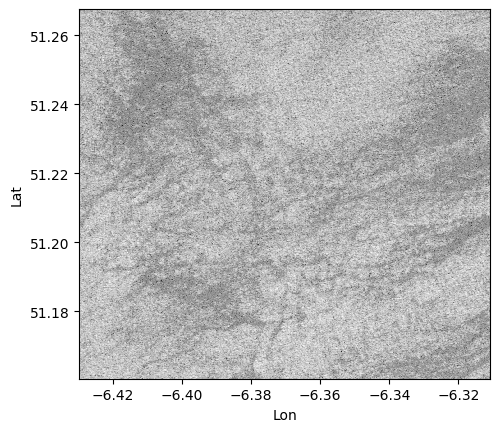

In [ ]:
from rasterio.plot import show

fig, ax = plt.subplots(1)
show(im[0], cmap='gray', interpolation="nearest", ax=ax, transform=im.transform)
ax.grid(False)
# ax.set_title(f"Predicted Map at iteration: {ii}")
ax.set_ylabel("Lat")
ax.set_xlabel("Lon")

## Load the Data

In [15]:
import rasterio as rio
# im_path = "D:\Bristol-AssenSAR-Project\Codes\Sentinel data download\S1 data\S1A_IW_GRDH_1SDV_20230924T181435_20230924T181500_050473_06141A_178A_COG.SAFE\measurement\s1a-iw-grd-vv-20230924t181435-20230924t181500-050473-06141a-001-cog.tiff"
im_path = "D:\Bristol-AssenSAR-Project\Codes\Sentinel data download\S1 data\S1A_IW_GRDH_1SDV_20230909T064020_20230909T064045_050247_060C68_5C3D.SAFE\measurement\s1a-iw-grd-vh-20230909t064020-20230909t064045-050247-060c68-002.tiff"

im=rio.open(im_path)

Text(0.5, 0, 'Lon')

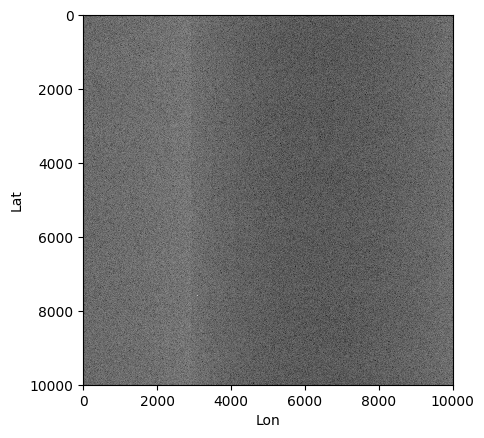

In [17]:
from rasterio.plot import show
subset = im.read(1, window=((5000, 15000), (15000, 25000)))

fig, ax = plt.subplots(1)
show(10*np.log10(subset), cmap='gray', interpolation="nearest", ax=ax, transform=im.transform)
ax.grid(False)
# ax.set_title(f"Predicted Map at iteration: {ii}")
ax.set_ylabel("Lat")
ax.set_xlabel("Lon")